---

## Part 1: 소개 및 설정 (Introduction & Setup)

이 파트에서는 필요한 라이브러리를 임포트하고, 분석에 사용할 배터리 데이터를 불러옵니다.

### 1.1 라이브러리 임포트

분석, 데이터 전처리, 모델링 및 시각화에 필요한 파이썬 라이브러리들을 불러옵니다.

In [ ]:
# --------------------------- 기본 유틸리티 ---------------------------
import os  # OS 관련 작업 (파일 경로 생성, 디렉토리 확인 등)을 위한 표준 라이브러리
import numpy as np  # 수치 계산을 위한 과학 컴퓨팅 라이브러리 (벡터화 연산, 난수 생성 등)
import pandas as pd  # 구조화된 데이터 처리를 위한 라이브러리 (DataFrame 기반 데이터 로딩/처리)
import pickle # GPR 모델 저장을 위한 직렬화 라이브러리

# --------------------------- 시각화 도구 ---------------------------
import matplotlib.pyplot as plt  # 기본 시각화 라이브러리 (선 그래프, 히스토그램 등)
import seaborn as sns  # 통계적 시각화를 지원하는 라이브러리 (히트맵, 분포도 등 고급 시각화)

# --------------------------- 전처리 및 ML 모델 ---------------------------
from sklearn.preprocessing import MinMaxScaler  # 데이터 정규화를 위한 스케일러 (0~1 범위로 정규화)

# --------------------------- 모델 구축 (딥러닝) ---------------------------
import tensorflow as tf  # Google의 딥러닝 프레임워크 (모델 생성, 학습, 추론 등 종합 지원)
from tensorflow.keras.models import Sequential  # 순차적 모델 구조 정의용 Keras API
from tensorflow.keras.layers import LSTM, Dense  # LSTM: 순환 신경망 레이어, Dense: 완전연결 레이어
from tensorflow.keras.models import load_model  # 저장된 Keras 모델을 로드하는 함수
from tensorflow.keras.losses import MeanSquaredError  # 손실 함수로 사용되는 MSE 객체 (직렬화 안전)

# --------------------------- 모델 평가 지표 ---------------------------
from sklearn.linear_model import Ridge  # L2 정규화를 적용한 선형 회귀 모델 (여기선 앙상블 블렌딩에 활용)
from sklearn.metrics import mean_squared_error, r2_score  # 회귀 성능 지표: MSE (오차 제곱 평균), R² (설명력)

### 1.2 실습용 데이터 및 모델 파일 업로드

Google Drive를 사용하지 않는 환경(강습회 등)을 위해 파일을 직접 업로드합니다. 아래 코드를 실행한 후, `B0005.csv`, `B0006.csv`, `B0007.csv`, `B0018.csv` 파일과 학습된 모델 파일들을 선택해 주세요.

In [ ]:
from google.colab import files
import os

# 실습에 필요한 파일들을 한번에 업로드합니다.
print("데이터 파일(CSV)과 모델 파일(.h5, .pkl)을 모두 선택하여 업로드해 주세요.")
uploaded = files.upload()

# 업로드된 파일 목록 확인
print("\n업로드된 파일 목록:")
for filename in uploaded.keys():
    print(f"- {filename}")

# 파일 경로를 현재 경로(/content/)로 통일
base_path = '/content/'

데이터 파일(CSV)과 모델 파일(.h5, .pkl)을 모두 선택하여 업로드해 주세요.


Saving B0005.csv to B0005 (2).csv
Saving B0006.csv to B0006 (2).csv
Saving B0007.csv to B0007 (2).csv
Saving B0018.csv to B0018 (2).csv
Saving battery_5_lstm_model.h5 to battery_5_lstm_model (2).h5
Saving battery_6_lstm_model.h5 to battery_6_lstm_model (2).h5
Saving battery_18_lstm_model.h5 to battery_18_lstm_model (2).h5

업로드된 파일 목록:
- B0005 (2).csv
- B0006 (2).csv
- B0007 (2).csv
- B0018 (2).csv
- battery_5_lstm_model (2).h5
- battery_6_lstm_model (2).h5
- battery_18_lstm_model (2).h5


## 1.3 NASA 배터리 데이터 불러오기

NASA PCoE Repository에서 제공하는 배터리 데이터인 CSV 파일을 마운트한 디렉토리에서 불러와 pandas DataFrame으로 저장합니다.

총 4가지 배터리의 데이터를 사용합니다. (B0005, B0006, B0007, B0018)

In [ ]:
import pandas as pd
import os

def get_uploaded_path(target_name):
    # 파일 업로드 시 이름 뒤에 (1) 등이 붙는 경우를 대비해 실제 파일명을 찾습니다.
    for f in os.listdir('/content/'):
        if f.startswith(target_name.split('.')[0]) and f.endswith('.csv'):
            return os.path.join('/content/', f)
    return os.path.join('/content/', target_name)

df_5 = pd.read_csv(get_uploaded_path('B0005.csv'))
df_6 = pd.read_csv(get_uploaded_path('B0006.csv'))
df_7 = pd.read_csv(get_uploaded_path('B0007.csv'))
df_18 = pd.read_csv(get_uploaded_path('B0018.csv'))

print("데이터 로드 완료.")

데이터 로드 완료.


## Part 2: 데이터 전처리 (Data Preprocessing)

이 파트에서는 배터리 분석에 중요한 SOH (State of Health)와 SoC (State of Charge) 피처를 계산하고, 데이터의 결측치를 확인 및 처리합니다.



### 2.1 SOH (State of Health) 및 SoC (State of Charge) 계산

배터리 수명 예측에서 중요한 지표인 SOH와 SoC를 계산하여 데이터프레임에 새로운 컬럼으로 추가합니다.

-   **SOH**: 배터리의 현재 최대 용량을 초기 최대 용량으로 나눈 값 (건강 상태)
-   **SoC**: 배터리의 현재 충전 상태를 나타내는 값 (주로 전압 기반으로 계산)


In [ ]:
# SOH (State of Health) 계산 함수 정의
def calculate_soh(df):
    """
    SOH(State of Health)를 계산합니다.

    Parameters:
        df (pd.DataFrame): capacity 정보를 포함한 DataFrame
        soh_init (float, optional): 초기 용량. 지정하지 않으면 첫 cycle의 capacity 사용

    Returns:
        pd.DataFrame: SOH 컬럼이 추가된 DataFrame
    """
    # 입력이 DataFrame인지 확인
    df = pd.DataFrame(df)
    # 초기 용량 (첫 번째 cycle의 capacity)을 기준 C로 설정
    C = df['capacity'].iloc[0]
    # SOH = 현재 용량 / 초기 용량
    df['SOH'] = df['capacity'] / C
    return df

In [ ]:
# SOC (State of Charge) 계산 함수 정의
def calculate_soc(df):
    """
    SoC(State of Charge)를 계산합니다.

    Parameters:
        df (pd.DataFrame): voltage_measured 컬럼을 포함한 DataFrame
        min_voltage (float): 방전 전압 하한
        max_voltage (float): 충전 전압 상한

    Returns:
        pd.DataFrame: SoC 컬럼이 추가된 DataFrame
    """
    # 입력이 DataFrame인지 확인
    df = pd.DataFrame(df)

    # SoC 계산을 위한 최소/최대 전압 정의
    # 데이터셋의 전체 최소/최대 전압을 사용하는 대신,
    # 일반적으로 배터리 종류에 따른 고정된 최소/최대 전압을 사용하는 것이 더 정확할 수 있습니다.
    # 여기서는 예시로 데이터셋의 min/max를 사용합니다.
    min_voltage = df['voltage_measured'].min()  # 완전 방전 시 최소 전압 (데이터 기반)
    max_voltage = df['voltage_measured'].max()  # 완전 충전 시 최대 전압 (데이터 기반)

    # 전압 기반 SoC 계산 공식: ((현재 전압 - 최소 전압) / (최대 전압 - 최소 전압)) * 100
    df['SoC'] = ((df['voltage_measured'] - min_voltage) / (max_voltage - min_voltage)) * 100

    # SoC 값이 0-100% 범위를 벗어나지 않도록 클리핑
    df['SoC'] = df['SoC'].clip(0, 100)

    return df


### 2.2 SOH 및 SoC 적용 및 데이터 확인

정의한 함수를 사용하여 모든 데이터프레임에 SOH와 SoC 컬럼을 추가하고, 추가된 컬럼을 확인합니다.


In [ ]:
# 모든 데이터프레임에 SOH 컬럼 추가
print("SOH 컬럼 추가 중...")
df_5 = calculate_soh(df_5)
df_6 = calculate_soh(df_6)
df_7 = calculate_soh(df_7)
df_18 = calculate_soh(df_18)
print("SOH 컬럼 추가 완료.")

# 모든 데이터프레임에 SOC 컬럼 추가
# 참고: SOC는 사이클 진행에 따른 변화보다는 특정 시점의 충전 상태를 나타내므로,
# 전체 데이터에 대해 계산하는 것보다 각 충방전 사이클 내에서 계산하는 것이 더 일반적입니다.
# 여기서는 예시로 전체 데이터에 대해 전압 기반 SOC를 계산합니다.
print("SOC 컬럼 추가 중...")
df_5 = calculate_soc(df_5)
df_6 = calculate_soc(df_6)
df_7 = calculate_soc(df_7)
df_18 = calculate_soc(df_18)
print("SOC 컬럼 추가 완료.")

# 각 데이터프레임의 처음 5행을 출력하여 SOH 및 SOC 컬럼이 잘 추가되었는지 확인
print("\ndf_5 head:")
print(df_5.head())

print("\ndf_6 head:")
print(df_6.head())

print("\ndf_7 head:")
print(df_7.head())

print("\ndf_18 head:")
print(df_18.head())

SOH 컬럼 추가 중...
SOH 컬럼 추가 완료.
SOC 컬럼 추가 중...
SOC 컬럼 추가 완료.

df_5 head:
   cycle  ambient_temperature             datetime  capacity  \
0      1                   24  2008-04-02 15:25:41  1.856487   
1      1                   24  2008-04-02 15:25:41  1.856487   
2      1                   24  2008-04-02 15:25:41  1.856487   
3      1                   24  2008-04-02 15:25:41  1.856487   
4      1                   24  2008-04-02 15:25:41  1.856487   

   voltage_measured  current_measured  temperature_measured  current_load  \
0          4.191492         -0.004902             24.330034       -0.0006   
1          4.190749         -0.001478             24.325993       -0.0006   
2          3.974871         -2.012528             24.389085       -1.9982   
3          3.951717         -2.013979             24.544752       -1.9982   
4          3.934352         -2.011144             24.731385       -1.9982   

   voltage_load    time  SOH        SoC  
0         0.000   0.000  1.0  98.221620 

### 2.3 결측치 확인 및 처리

데이터에 결측값(NaN)이 있는지 확인하고, 있다면 적절한 방법(예: 이동 평균)으로 채워 넣습니다.
이 데이터셋에서는 결측치가 없는 것으로 알려져 있지만, 실제 데이터 분석에서는 필수적인 과정입니다.

In [ ]:
# 데이터프레임들을 리스트에 담아 반복 처리
dfs = {'df_5': df_5, 'df_6': df_6, 'df_7': df_7, 'df_18': df_18}

# 각 데이터프레임의 결측치 확인 및 처리
print("\n--- 결측치 확인 및 처리 ---")
for name, df in dfs.items():
    print(f"\nDataFrame {name} 정보:")
    # 데이터프레임의 기본 정보 (컬럼 타입, 결측치 개수 등) 출력
    df.info()

    # 결측치 개수 확인
    print(f"\nDataFrame {name} 초기 결측치:")
    missing_values = df.isnull().sum()
    # 결측치가 있는 컬럼만 출력
    print(missing_values[missing_values > 0])

    # (실습용 코드) 만약 결측치가 있다면 숫자형 컬럼에 대해 이동 평균으로 채우는 코드
    # 이 데이터셋에서는 결측치가 없으므로 실제로는 동작하지 않음
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    print(f"\nDataFrame {name} 숫자형 컬럼에 이동 평균으로 결측치 채우기 시도 (결측치 없을 경우 변화 없음):")
    for col in numeric_cols:
         # window=4: 앞선 4개 값의 평균 사용, min_periods=1: 최소 1개 값이 있으면 계산
        df[col] = df[col].fillna(df[col].rolling(window=4, min_periods=1).mean())

    # 결측치 처리 후 다시 확인
    print(f"DataFrame {name} 처리 후 결측치:")
    missing_values_after_fill = df.isnull().sum()
    print(missing_values_after_fill[missing_values_after_fill > 0])

print("\n--- 결측치 확인 및 처리 완료 ---")


--- 결측치 확인 및 처리 ---

DataFrame df_5 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50285 entries, 0 to 50284
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cycle                 50285 non-null  int64  
 1   ambient_temperature   50285 non-null  int64  
 2   datetime              50285 non-null  object 
 3   capacity              50285 non-null  float64
 4   voltage_measured      50285 non-null  float64
 5   current_measured      50285 non-null  float64
 6   temperature_measured  50285 non-null  float64
 7   current_load          50285 non-null  float64
 8   voltage_load          50285 non-null  float64
 9   time                  50285 non-null  float64
 10  SOH                   50285 non-null  float64
 11  SoC                   50285 non-null  float64
dtypes: float64(9), int64(2), object(1)
memory usage: 4.6+ MB

DataFrame df_5 초기 결측치:
Series([], dtype: int64)

DataFrame df_5 숫자형 컬럼에 이

## Part 3: 특징 추출 및 상관관계 분석 (Feature Engineering & Correlation analysis)

이어서 머신러닝/딥러닝 학습을 위한 특징을 추출하고, 상관관계 분석을 수행합니다.

### 3.1 SOH vs. Cycle 시각화

각 배터리의 SOH가 사이클이 진행됨에 따라 어떻게 감소하는지 시각화합니다.
배터리 수명 임계값(0.75)을 기준으로 해당 사이클을 찾아 사용 가능한 수명(RUL)을 함께 시각화합니다


B0005: 수명 종료 시점(SOH < 0.75)은 126 사이클입니다.
B0006: 수명 종료 시점(SOH < 0.75)은 70 사이클입니다.
B0007: 수명 종료 시점(SOH < 0.75)은 160 사이클입니다.
B0018: 수명 종료 시점(SOH < 0.75)은 99 사이클입니다.


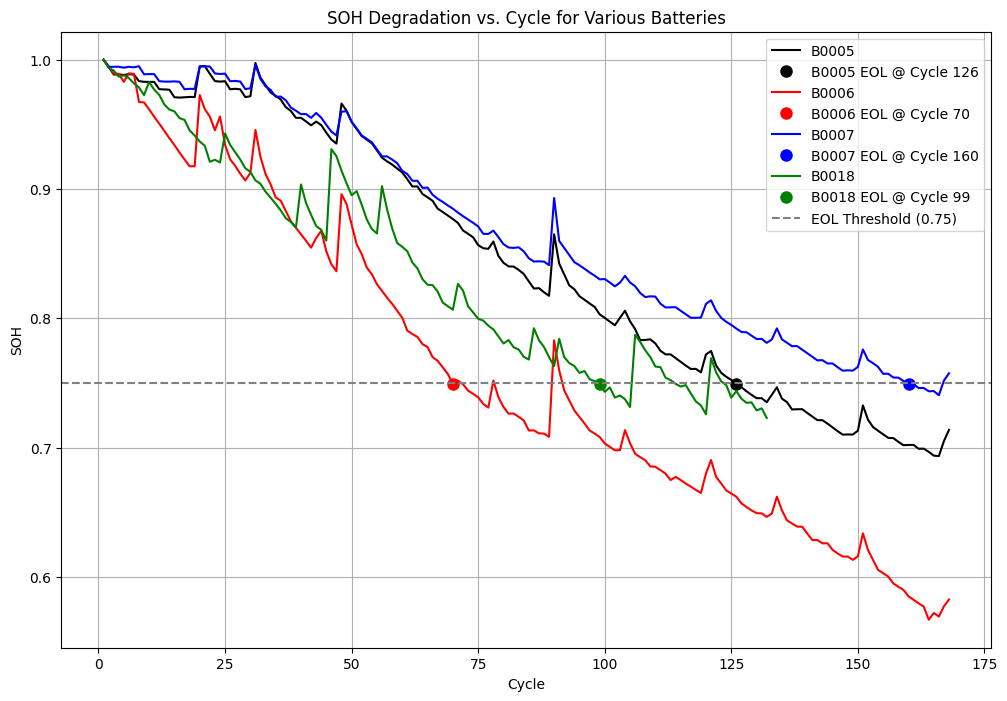

In [ ]:
# 일반적으로 배터리 용량이 초기 용량의 70~80%가 되면 수명이 다했다고 봅니다.
# 여기서는 SOH(State of Health)가 0.75(75%) 이하로 떨어지는 것을 "수명 종료" 기준으로 정합니다.
threshold = 0.75

# --- 2단계: 분석 대상 및 시각화 옵션 준비 ---
# 분석할 배터리 데이터(데이터프레임)와 각각의 이름을 리스트로 준비합니다.
df_list = [df_5, df_6, df_7, df_18]
batteries = ['B0005', 'B0006', 'B0007', 'B0018']
# 각 배터리를 그래프에서 쉽게 구분할 수 있도록 색상을 지정합니다.
colors = ['black', 'red', 'blue', 'green']

plt.figure(figsize=(12, 8)) # 그래프 크기를 설정합니다.

# --- 3단계: 배터리별 데이터 시각화 및 수명 분석 (핵심 로직) ---
# zip 함수는 여러 리스트를 하나로 묶어, 같은 순서의 항목끼리 짝을 지어줍니다.
# (데이터, 이름, 색상) 세트를 하나씩 꺼내와 반복 작업을 수행합니다.
for df, battery, color in zip(df_list, batteries, colors):
    # (A) 시간에 따른 SOH 변화를 선 그래프로 그립니다. X축은 사용 횟수(cycle), Y축은 배터리 건강 상태(SOH)입니다.
    plt.plot(df['cycle'], df['SOH'], label=battery, color=color)

    # (B) SOH가 수명 기준(threshold) 아래로 떨어진 지점을 모두 찾습니다.
    # np.where는 조건이 참(True)인 위치(인덱스)를 찾아주는 함수입니다.
    below_threshold_indices = np.where(df['SOH'] < threshold)[0]

    # (C) 수명 종료 시점을 확인하고 표시합니다.
    # 만약 기준 아래로 떨어진 지점이 하나라도 있다면,
    if len(below_threshold_indices) > 0:
        # 그중 가장 첫 번째 지점(가장 먼저 수명이 다한 시점)의 인덱스를 가져옵니다.
        first_below_threshold_index = below_threshold_indices[0]

        # 분석 결과를 텍스트로 출력하여 사용자에게 알려줍니다.
        eol_cycle = df["cycle"].iloc[first_below_threshold_index]
        print(f'{battery}: 수명 종료 시점(SOH < {threshold})은 {eol_cycle} 사이클입니다.')

        # 해당 지점에 눈에 띄게 동그라미 마커를 찍습니다.
        # .iloc[index]는 데이터프레임에서 특정 위치의 값을 정확히 찾아줍니다.
        plt.plot(df['cycle'].iloc[first_below_threshold_index], df['SOH'].iloc[first_below_threshold_index],
                 'o', color=color, markersize=8, label=f'{battery} EOL @ Cycle {eol_cycle}')
    else:
        # 기준 아래로 떨어진 적이 없다면, 아직 수명이 남아있다는 의미입니다.
        print(f'{battery}: 이 배터리는 실험 기간 동안 수명이 다하지 않았습니다.')

# --- 4단계: 보고서 가독성 높이기 (Annotation & Formatting) ---
# (A) 모든 배터리에 공통으로 적용되는 수명 기준선(threshold)을 점선으로 표시합니다.
plt.axhline(y=threshold, color='gray', linestyle='--', label=f'EOL Threshold ({threshold})')

# (B) 그래프의 제목과 X, Y축에 대한 설명을 추가합니다.
plt.xlabel('Cycle') # X축 레이블
plt.ylabel('SOH')   # Y축 레이블
plt.title('SOH Degradation vs. Cycle for Various Batteries') # 그래프 전체 제목

# (C) 범례(legend)와 그리드(grid)를 추가하여 어떤 선이 어떤 배터리를 의미하는지 명확히 하고, 값을 읽기 쉽게 만듭니다.
plt.legend()
plt.grid(True)

# --- 5단계: 최종 결과물 출력 ---
# 완성된 그래프를 화면에 보여줍니다.
plt.show()

### 3.2 B0005 배터리의 사이클별 시계열 측정값 시각화

B0005 배터리의 여러 사이클에 걸쳐 시간(time)에 따른 다양한 측정값(SoC, 전압, 전류, 온도 등)의 변화를 시각화합니다.
이를 통해 각 사이클 내에서 어떤 측정값이 어떻게 변화하는지, 그리고 사이클 간에 어떤 차이가 있는지 파악할 수 있습니다.


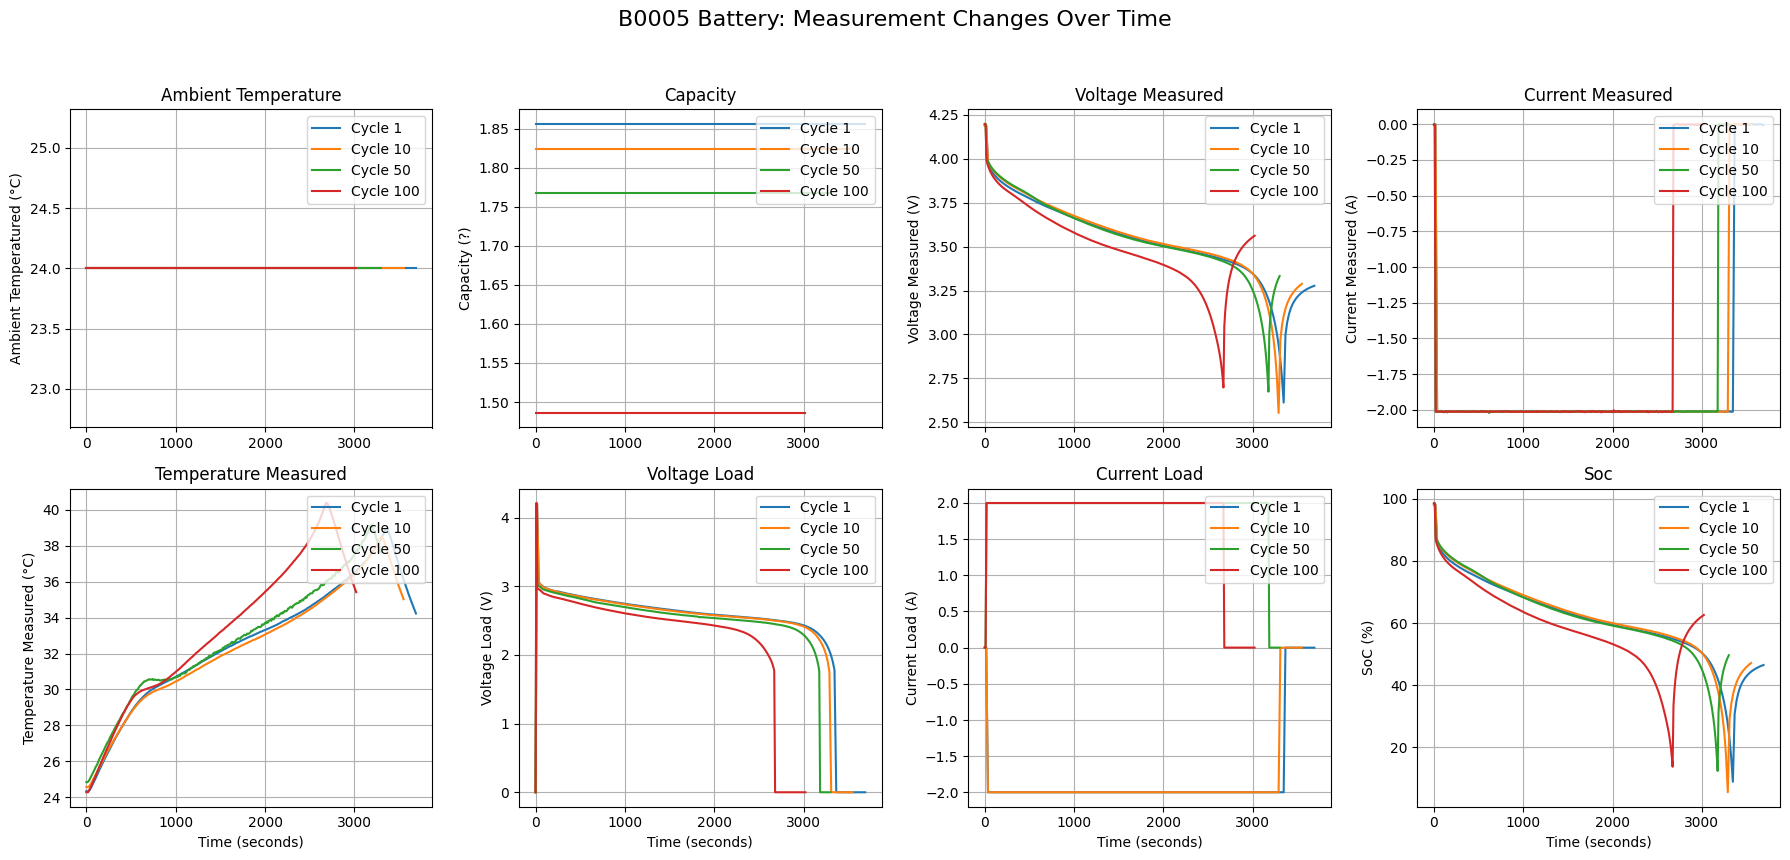

In [ ]:
# --- 1단계: 분석 대상 선정 ---
# 모든 충전/방전 기록을 다 보면 너무 복잡하니,
# 배터리 전체 사이클 중 특정 시점(1, 10, 50, 100번째 사이클)만 골라서 확인.
cycles_to_plot = [1, 10, 50, 100]

# --- 2단계: 분석할 항목(Parameter) 정의 ---
# 6개 그래프에 각각 어떤 데이터를 그릴지 계획을 세웁니다.
# 코드를 깔끔하게 관리하기 위해 파이썬의 딕셔너리(Dictionary)를 사용합니다.
metrics = {
    'ambient_temperature': 'Ambient Temperatured (°C)',
    'capacity': 'Capacity (?)',
    'voltage_measured': 'Voltage Measured (V)',
    'current_measured': 'Current Measured (A)',
    'temperature_measured': 'Temperature Measured (°C)',
    'voltage_load': 'Voltage Load (V)',
    'current_load': 'Current Load (A)',
    'SoC': 'SoC (%)',
}
metric_keys = list(metrics.keys()) # 다루기 쉽게 키 값만 리스트로 만듭니다.
# --- 3단계: 그래프 구성 ---
# 총 8개의 그래프를 그릴 것이므로, 2행 4열의 격자(Grid) 형태로 구성합니다.
# fig는 그림 전체, axs는 8개의 개별 그래프를 담는 배열입니다.
# axs는 2x4 행렬처럼 다룰 수 있습니다. (예: axs[0, 0]은 첫 번째 칸)
fig, axs = plt.subplots(2, 4, figsize=(18, 9))

# 1단계에서 고른 각 사이클(1, 10, 50, 100)에 대해 반복 작업을 수행합니다.
for cycle in cycles_to_plot:
    # (A) 전체 데이터(df_5)에서 현재 분석 중인 사이클의 데이터만 필터링합니다.
    df_cycle = df_5[df_5['cycle'] == cycle]

    # (B) 8개의 각 칸(subplot)에 시간(time)에 따른 측정값을 그립니다.
    # 이 과정이 반복되면서, 각 그래프에는 4개의 선(1, 10, 50, 100 사이클)이 겹쳐서 그려집니다.
    axs[0, 0].plot(df_cycle['time'], df_cycle[metric_keys[0]], label=f'Cycle {cycle}') # 1행 1열
    axs[0, 1].plot(df_cycle['time'], df_cycle[metric_keys[1]], label=f'Cycle {cycle}') # 1행 2열
    axs[0, 2].plot(df_cycle['time'], df_cycle[metric_keys[2]], label=f'Cycle {cycle}') # 1행 3열
    axs[0, 3].plot(df_cycle['time'], df_cycle[metric_keys[3]], label=f'Cycle {cycle}') # 1행 4열
    axs[1, 0].plot(df_cycle['time'], df_cycle[metric_keys[4]], label=f'Cycle {cycle}') # 2행 1열
    axs[1, 1].plot(df_cycle['time'], df_cycle[metric_keys[5]], label=f'Cycle {cycle}') # 2행 2열
    axs[1, 2].plot(df_cycle['time'], df_cycle[metric_keys[6]], label=f'Cycle {cycle}') # 2행 3열
    axs[1, 3].plot(df_cycle['time'], df_cycle[metric_keys[7]], label=f'Cycle {cycle}') # 2행 4열


# 위쪽 행(row 0)의 그래프들 꾸미기
for i, key in enumerate(metric_keys[:4]): # Changed range to include 4 metrics
    ax = axs[0, i]
    ax.set_ylabel(metrics[key])                # Y축 레이블 (예: 'SoC (%)')
    ax.set_title(key.replace('_', ' ').title()) # 각 그래프의 소제목 (예: 'Voltage Measured')
    ax.legend(loc='upper right')               # 범례 (어떤 선이 몇 번째 사이클인지 표시)
    ax.grid(True)                              # 가독성을 위한 그리드(격자무늬) 추가

# 아래쪽 행(row 1)의 그래프들 꾸미기
for i, key in enumerate(metric_keys[4:]): # Changed starting index to 4
    ax = axs[1, i]
    ax.set_ylabel(metrics[key])
    ax.set_title(key.replace('_', ' ').title())
    ax.legend(loc='upper right')
    ax.grid(True)
    ax.set_xlabel('Time (seconds)')             # X축 is common for the bottom row

# --- 4단계: 최종 완성 및 출력 ---
# 보고서 전체의 대표 제목을 설정합니다.
fig.suptitle('B0005 Battery: Measurement Changes Over Time', fontsize=16)

# 그래프 제목과 축 레이블이 겹치지 않도록 자동으로 레이아웃을 조정합니다.
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# 완성된 보고서(그래프)를 화면에 출력합니다.
plt.show()


### 3.3 사이클 별 시계열 특징의 상관관계 분석

여러 배터리의 시계열 데이터들 사이에 어떤 상관관계가 있는지 히트맵으로 시각화합니다.
이를 통해 모델 입력 피처 선택 등에 활용할 수 있습니다.

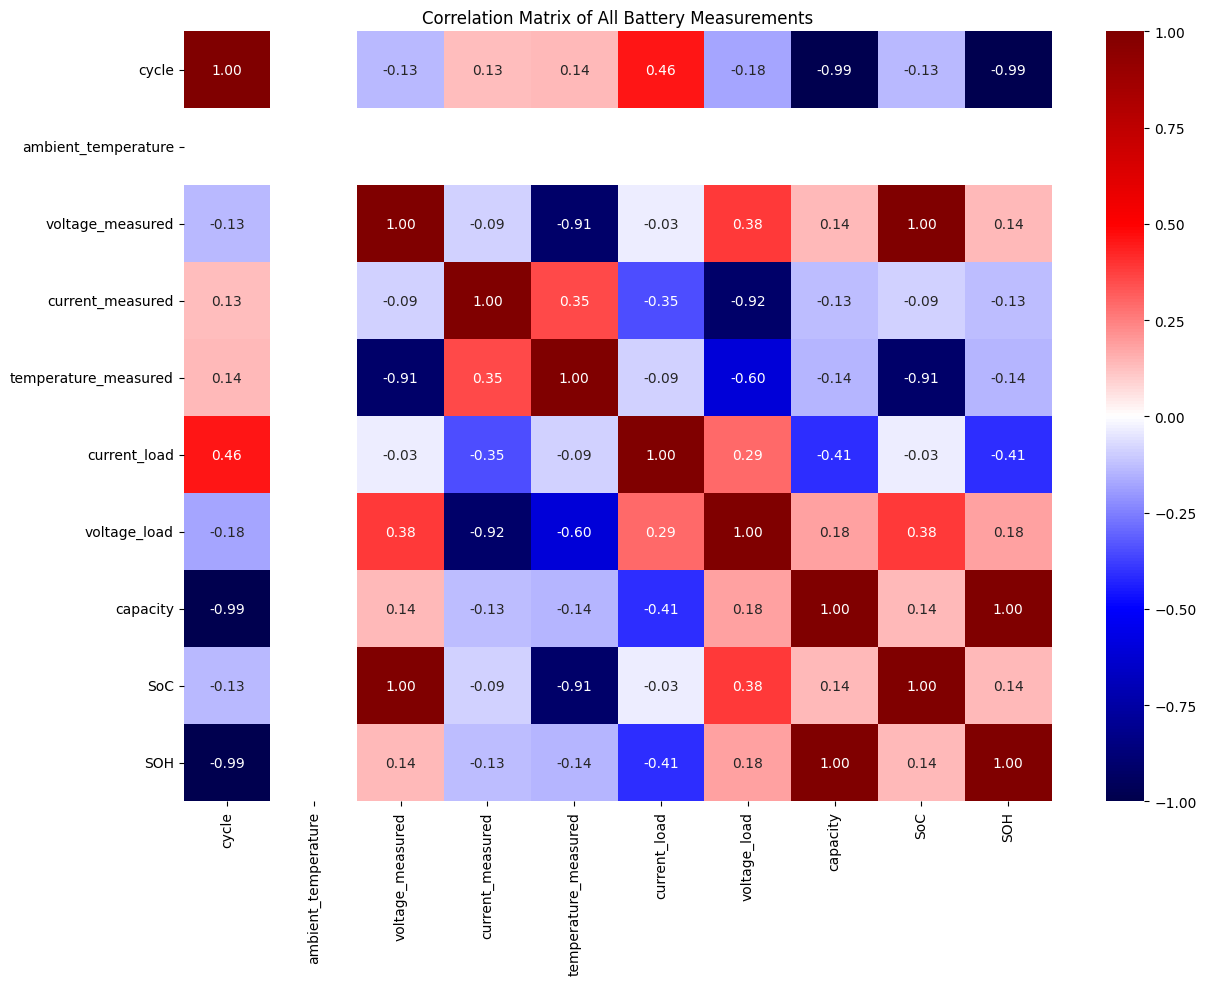

In [ ]:
# --- 1단계: 데이터 준비 (Data Preparation) ---
# 분석에 의미 있는 수치형(numerical) 데이터 컬럼들을 선택합니다.
# 'time'처럼 단순히 누적되는 값은 변수 간의 관계를 파악하는 데 방해가 될 수 있어 제외합니다.
common_columns = [
    'cycle', 'ambient_temperature', 'voltage_measured', 'current_measured',
    'temperature_measured', 'current_load', 'voltage_load', 'capacity', 'SoC', 'SOH'
    ]
time_feature_df_5 = df_5[common_columns]

# --- 2단계: 상관관계 분석 (Correlation Analysis) ---
#  데이터프레임에서 .corr() 메소드를 호출하여 '상관관계 행렬(Correlation Matrix)'을 계산합니다.
# 이 행렬은 각 변수 쌍이 얼마나 강하게 연관되어 있는지를 -1에서 +1 사이의 값으로 나타냅니다.
correlation_matrix = time_feature_df_5.corr()

# --- 3단계: 결과 시각화 (Visualization with Heatmap) ---
# 상관관계 행렬을 '히트맵(Heatmap)'으로 시각화합니다.
# 상관관계 값의 크기를 색상의 차이로 표현하여 패턴을 쉽게 파악합니다.
plt.figure(figsize=(14, 10)) # 그래프의 크기를 설정합니다.

sns.heatmap(
    correlation_matrix,
    # 각 셀에 상관계수 값을 숫자로 표시합니다.
    annot=True,
    # 0을 중심으로 양수는 붉은색, 음수는 푸른색인 색상 맵을 지정합니다.
    cmap='seismic',
    # 숫자를 소수점 둘째 자리까지 표시합니다.
    fmt='.2f',
    # 색상 스케일의 범위를 -1과 1로 고정.
    vmin=-1, vmax=1
)

#   - 상관계수 +1: 완벽한 양의 상관관계.
#     (예: 배터리 'capacity'가 높을수록 'SOH'도 높다)
#   - 상관계수 -1: 완벽한 음의 상관관계.
#     (예: 'cycle'이 늘어날수록 'SOH'는 감소한다)
#   - 상관계수 0: 상관관계 없음.

plt.title('Correlation Matrix of All Battery Measurements') # 그래프의 전체 제목
plt.show() # 완성된 그래프를 화면에 출력합니다.


### 3.4 사이클 별 유효 특징 추출

시계열 특징을 입력으로 사용하지 못하는 경우, 배터리의 시계열 데이터에서 사이클 별로 유효한 특징을 추출하여 학습을 위한 입력으로 사용합니다.



In [ ]:
def extract_features_from_cycles(cycle_list):
    feature_rows = []

    for i, df in enumerate(cycle_list):
        df = df.copy()

        time = df['time'].values
        voltage = df['voltage_measured'].values
        current = df['current_measured'].values
        temperature = df['temperature_measured'].values
        SOH = df['SOH'].values

        features = {
            "cycle_index": i,
            "avg_voltage": np.mean(voltage),
            "var_voltage": np.var(voltage),
            "avg_current": np.mean(current),
            "var_current": np.var(current),
            "avg_temperature": np.mean(temperature),
            "var_temperature": np.var(temperature),
            "discharge_time": time[-1] - time[0],
            "temperature_rise": temperature[-1] - temperature[0],
            "SOH": SOH[-1] if isinstance(SOH, np.ndarray) else SOH,
        }

        feature_rows.append(features)

    return pd.DataFrame(feature_rows)

# 사이클 분할 및 피처 추출
cycle_list_5 = [df_5[df_5['cycle'] == c].copy() for c in df_5['cycle'].unique()]
features_df_5 = extract_features_from_cycles(cycle_list_5)

### 3.5 사이클 별 추출 특징 시각화

사이클 별로 추출한 유효한 특징에 대하여 시각화를 수행합니다.

이를 통해 사이클에 따라 특징들이 어떻게 변화하는지 파악할 수 있습니다.

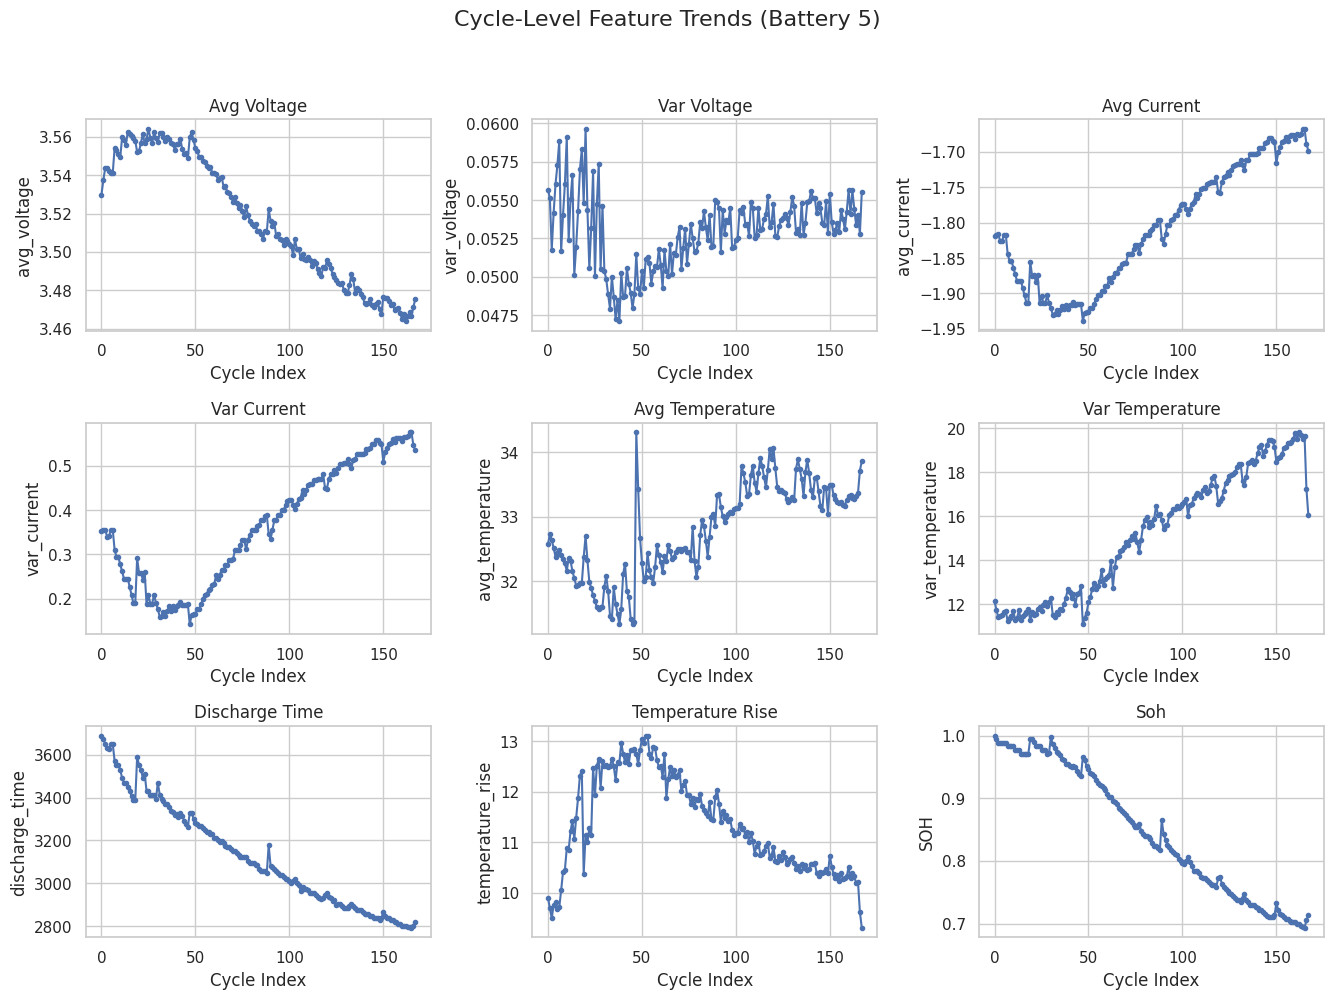

In [ ]:
def plot_cycle_feature_trends(features_df, battery_id=None):
    """
    extract_features_from_cycles()로 생성된 데이터프레임을 시각화합니다.

    Args:
        features_df (pd.DataFrame): 사이클별 피처 데이터프레임
        battery_id (int, optional): 그래프 제목에 사용할 배터리 ID
    """
    sns.set(style='whitegrid')

    # 시각화할 feature 목록 (SOH 포함 16개)
    plot_features = [
        'avg_voltage', 'var_voltage',
        'avg_current', 'var_current',
        'avg_temperature', 'var_temperature',
        'discharge_time', 'temperature_rise', 'SOH'
    ]

    n_plots = len(plot_features)
    n_cols = 3
    n_rows = (n_plots + n_cols - 1) // n_cols

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 3.5 * n_rows))
    axs = axs.flatten()

    for i, feature in enumerate(plot_features):
        ax = axs[i]
        ax.plot(features_df['cycle_index'], features_df[feature], marker='o', markersize=3)
        ax.set_title(feature.replace('_', ' ').title())
        ax.set_xlabel('Cycle Index')
        ax.set_ylabel(feature)
        ax.grid(True)

    # 빈 subplot 숨기기
    for j in range(i + 1, len(axs)):
        axs[j].axis('off')

    title = f"Cycle-Level Feature Trends" + (f" (Battery {battery_id})" if battery_id else "")
    fig.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# 시각화 실행
plot_cycle_feature_trends(features_df_5, battery_id=5)

### 3.6 사이클별 추출 특징 상관관계 분석

여러 배터리의 사이클 별 특징 데이터에 대하여 각 특징값들 사이에 어떤 상관관계가 있는지 히트맵으로 시각화합니다.

이를 통해 모델 입력 피처 선택 등에 활용할 수 있습니다.

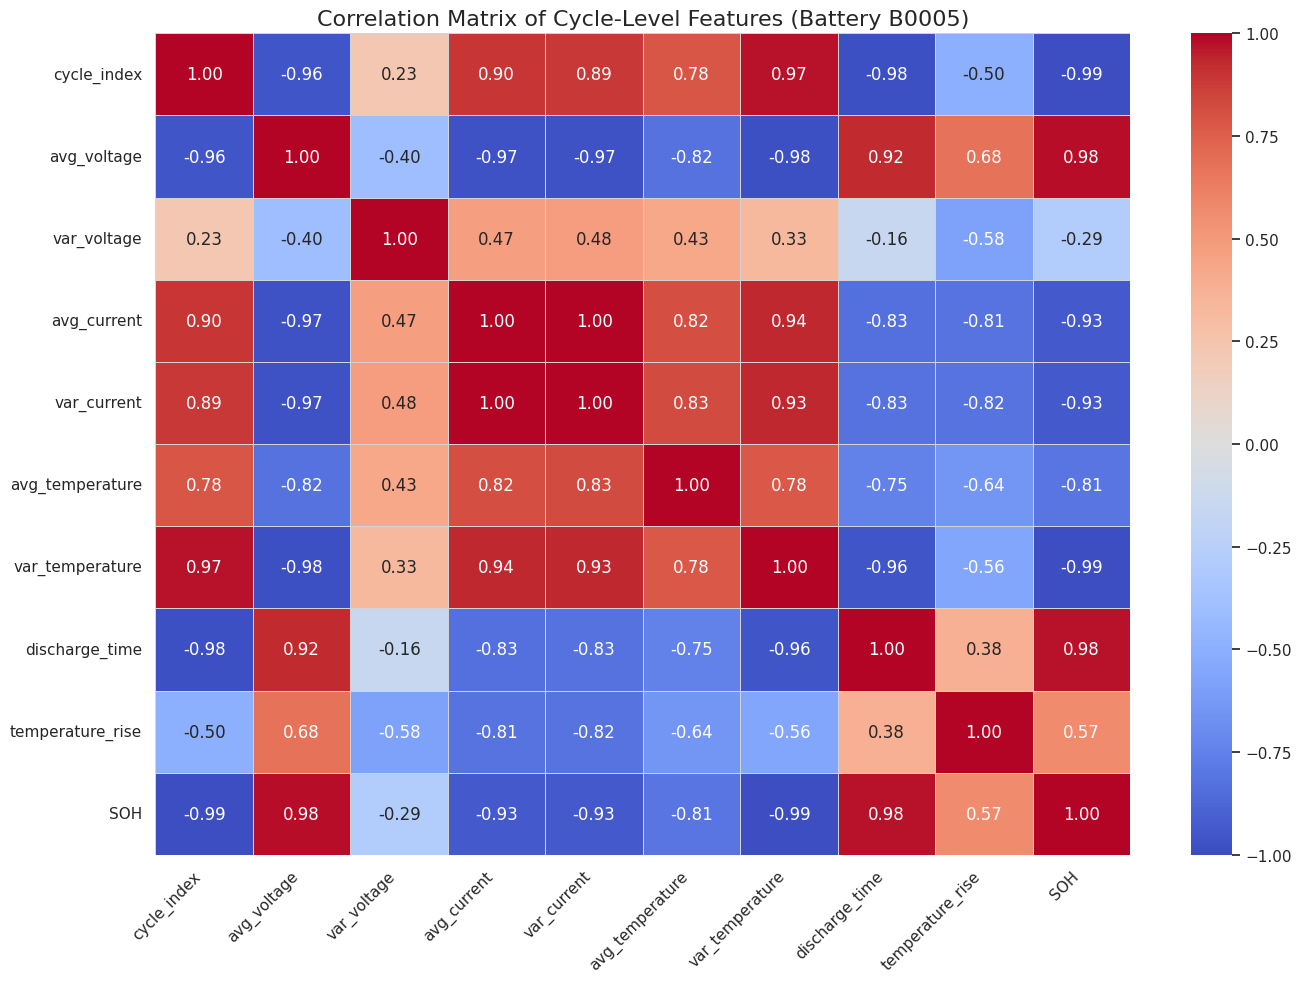

In [ ]:
# --- 1단계: 상관관계 분석 ---
correlation_matrix_5 = features_df_5.corr()

# --- 2단계: 히트맵 시각화 ---
plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation_matrix_5,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='lightgray'
)
plt.title('Correlation Matrix of Cycle-Level Features (Battery B0005)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

이탤릭체 텍스트
## Part 4: 모델 개발 (LSTM 모델) (Model Development)

이 파트에서는 시계열 데이터 예측에 강점을 가진 LSTM(Long Short-Term Memory) 모델을 구축하고 학습시킵니다.

LSTM의 경우 시계열 입력을 받기 때문에 그에 맞게 데이터를 시퀀스로 구성하여 학습합니다.

SOH를 예측하기 위해 이전 시점의 데이터 시퀀스를 입력으로 사용합니다.



### 4.1 LSTM 모델 관련 함수 정의

-  시계열 예측을 위해 데이터를 지정된 길이의 시퀀스(입력)와 해당 시퀀스 다음 시점의 값(출력)으로 변환하는 함수
-  데이터프레임을 받아 LSTM 모델을 정의, 스케일링, 시퀀스 생성, 모델 학습까지 수행하는 함수


In [ ]:
# 시계열 데이터셋을 LSTM 학습에 맞는 (샘플 수, 시퀀스 길이, 피처 수) 형태로 변환하는 함수
def create_sequences(X, y, seq_length):
    """
    시계열 데이터를 지정된 길이의 시퀀스로 변환합니다.

    Args:
    X (np.ndarray): 입력 피처 배열 (스케일링 된 상태)
    y (np.ndarray): 타겟 값 배열 (스케일링 된 상태)
    seq_length (int): 시퀀스의 길이 (과거 몇 시점의 데이터를 볼 것인가)

    Returns:
    tuple: (입력 시퀀스 배열 X_seq, 타겟 값 배열 y_seq)
           X_seq.shape = (샘플 수, seq_length, 피처 수)
           y_seq.shape = (샘플 수, 1)
    """
    sequences = [] # 입력 시퀀스를 저장할 리스트
    targets = []   # 타겟 값을 저장할 리스트
    # 데이터를 슬라이딩 윈도우 방식으로 이동하며 시퀀스 생성
    # 마지막 seq_length 시점의 데이터는 시퀀스로 사용될 수 없으므로 len(X) - seq_length 까지만 반복
    for i in range(len(X) - seq_length):
        # i부터 i+seq_length까지의 데이터를 하나의 시퀀스로 사용
        sequences.append(X[i:i + seq_length])
        # 시퀀스 바로 다음 시점(i+seq_length)의 값을 이 시퀀스의 타겟으로 사용
        targets.append(y[i + seq_length])
    # 리스트를 numpy 배열로 변환하여 반환
    return np.array(sequences), np.array(targets)

In [ ]:
def preprocess_timeseries(df, seq_length=8):
    """
    데이터프레임을 받아 스케일링 및 시계열 시퀀스를 생성하는 전처리 함수.

    Args:
        df (pd.DataFrame): 원본 데이터프레임
        seq_length (int): 시퀀스 길이

    Returns:
        tuple: (X_seq, y_seq, scaler_X, scaler_y)
    """
    df = df.copy()
    df['datetime'] = pd.to_datetime(df['datetime'])
    df = df.sort_values(by='datetime')

    features = ['cycle', 'ambient_temperature', 'voltage_measured', 'current_measured',
                'temperature_measured', 'current_load', 'voltage_load', 'SoC']
    target = 'SOH'

    X = df[features].values
    y = df[target].values

    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    X_scaled = scaler_X.fit_transform(X)
    y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

    X_seq, y_seq = create_sequences(X_scaled, y_scaled, seq_length)

    return X_seq, y_seq, scaler_X, scaler_y

In [ ]:
def train_lstm_model(X_seq, y_seq, seq_length, epochs=10, batch_size=32):
    """
    주어진 시퀀스 데이터를 이용해 LSTM 모델을 학습.

    Args:
        X_seq (np.ndarray): 시퀀스 입력 데이터 (샘플 수, seq_length, 피처 수)
        y_seq (np.ndarray): 타겟 값 (샘플 수, 1)
        seq_length (int): 시퀀스 길이
        epochs (int): 에포크 수
        batch_size (int): 배치 크기

    Returns:
        tuple: (학습된 모델, 학습 이력)
    """
    model = Sequential()
    model.add(LSTM(50, activation='relu', input_shape=(seq_length, X_seq.shape[2])))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')

    history = model.fit(X_seq, y_seq, epochs=epochs, batch_size=batch_size,
                        validation_split=0.1, verbose=1)

    # 시각화
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    return model, history

### 4.2 각 배터리 데이터로 LSTM 모델 학습

학습용으로 준비된 데이터프레임 (df_5, df_6, df_18) 각각에 대해 독립적으로 LSTM 모델을 학습시킵니다.
각 모델은 해당 배터리의 특성에 맞춰 학습됩니다.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

def create_sequences_local(X, y, seq_length):
    sequences = []
    targets = []
    for i in range(len(X) - seq_length):
        sequences.append(X[i:i + seq_length])
        targets.append(y[i + seq_length])
    return np.array(sequences), np.array(targets)

def calculate_soc_local(df):
    min_v, max_v = df['voltage_measured'].min(), df['voltage_measured'].max()
    df['SoC'] = ((df['voltage_measured'] - min_v) / (max_v - min_v)) * 100
    df['SoC'] = df['SoC'].clip(0, 100)
    return df

def preprocess_timeseries_local(df, seq_length=8):
    df = df.copy()
    if 'SOH' not in df.columns:
        df['SOH'] = df['capacity'] / df['capacity'].iloc[0]
    if 'SoC' not in df.columns:
        df = calculate_soc_local(df)
    df['datetime'] = pd.to_datetime(df['datetime'])
    df = df.sort_values(by='datetime')
    features = ['cycle', 'ambient_temperature', 'voltage_measured', 'current_measured', 'temperature_measured', 'current_load', 'voltage_load', 'SoC']
    target = 'SOH'
    X = df[features].values
    y = df[target].values
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    X_scaled = scaler_X.fit_transform(X)
    y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))
    X_seq, y_seq = create_sequences_local(X_scaled, y_scaled, seq_length)
    return X_seq, y_seq, scaler_X, scaler_y

save_dir = "/content/"
dataframes_lstm = [df_5, df_6, df_18]
battery_ids_lstm = [5, 6, 18]

X_seqs_lstm = []
y_seqs_lstm = []
scalers_X_lstm = []
scalers_y_lstm = []

for i, df in enumerate(dataframes_lstm):
    print(f"\n>>> Battery {battery_ids_lstm[i]} 데이터 전처리 시작...")
    X_seq, y_seq, scaler_X, scaler_y = preprocess_timeseries_local(df, seq_length=8)
    X_seqs_lstm.append(X_seq)
    y_seqs_lstm.append(y_seq)
    scalers_X_lstm.append(scaler_X)
    scalers_y_lstm.append(scaler_y)

print("\n모든 배터리 데이터의 LSTM 전처리가 완료되었습니다.")


>>> Battery 5 데이터 전처리 시작...

>>> Battery 6 데이터 전처리 시작...

>>> Battery 18 데이터 전처리 시작...

모든 배터리 데이터의 LSTM 전처리가 완료되었습니다.


In [ ]:
# === LSTM 학습 단계 수정 ===
models = []
histories = []

# LSTM 전용으로 전처리된 X_seqs_lstm 및 battery_ids_lstm 사용
for i in range(len(battery_ids_lstm)):
    print(f"\n>>> Battery {battery_ids_lstm[i]} 모델 학습 시작...")

    # X_seqs[i] 대신 X_seqs_lstm[i] 사용 (시각화용 변수 혼동 방지)
    X_input = X_seqs_lstm[i]
    y_input = y_seqs_lstm[i]

    # train_lstm_model 함수 호출
    model, history = train_lstm_model(X_input, y_input, seq_length=8, epochs=10, batch_size=32)

    model_path = os.path.join(save_dir, f"battery_{battery_ids_lstm[i]}_lstm_model.h5")
    model.save(model_path)

    models.append(model)
    histories.append(history)

    print(f">>> Battery {battery_ids_lstm[i]} 학습 완료 및 모델 저장: {model_path}")


>>> Battery 5 모델 학습 시작...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


KeyboardInterrupt: 

### 4.3 각 배터리 데이터로 LSTM 모델 불러오기
학습된 모델이 있다면 불러와서 사용할 수 있습니다.

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.losses import MeanSquaredError
import os

def get_model_path(battery_id):
    target = f"battery_{battery_id}_lstm_model"
    for f in os.listdir('/content/'):
        if f.startswith(target) and f.endswith('.h5'):
            return os.path.join('/content/', f)
    return None

models = []
battery_ids = [5, 6, 18]

for b_id in battery_ids:
    path = get_model_path(b_id)
    if path and os.path.exists(path):
        model = load_model(path, compile=False)
        model.compile(loss=MeanSquaredError(), optimizer='adam', metrics=['mae'])
        models.append(model)
        print(f">>> Battery {b_id} 모델 로드 완료: {path}")
    else:
        print(f">>> 경고: Battery {b_id} 모델 파일을 찾을 수 없습니다.")

>>> Battery 5 모델 로드 완료: /content/battery_5_lstm_model (2).h5
>>> Battery 6 모델 로드 완료: /content/battery_6_lstm_model.h5
>>> Battery 18 모델 로드 완료: /content/battery_18_lstm_model (1).h5


### 4.4 테스트 데이터 준비 및 개별 모델 예측

테스트 데이터(df7_test)를 학습 시 사용한 피처와 동일한 형태로 준비하고, 각 학습 모델에 넣어 예측을 수행합니다.


In [ ]:
# --- 1단계: 테스트 데이터 준비 ---
# B0007 배터리 데이터를 테스트 세트로 사용
df_test = df_7.copy()
df_test['datetime'] = pd.to_datetime(df_test['datetime'])  # 시간 형식 변환
df_test = df_test.sort_values(by='datetime')  # 시간 순 정렬

# 테스트 입력 피처 정의 (훈련과 동일한 구성)
features = ['cycle', 'ambient_temperature', 'voltage_measured', 'current_measured',
            'temperature_measured', 'current_load', 'voltage_load', 'SoC']
X_test = df_test[features].values

# SOH 레이블 준비 (시퀀스 길이만큼 지연 필요)
seq_length = 8  # LSTM 입력 시퀀스 길이
y_test_actual = df_test['SOH'].values[seq_length:]

# --- 2단계: 모델 예측 수행 ---
# 예측 결과와 EOL 추정값 저장용 리스트
model_predictions = []
eol_predictions = []

# 각 모델별 이름 지정
model_names = ['Model trained on B0005', 'Model trained on B0006', 'Model trained on B0018']

# 훈련된 모델 3개에 대해 각각 예측 수행
for i, model in enumerate(models):
    print(f"--- '{model_names[i]}' 예측 중 ---")

    # LSTM 전용 스케일러(scalers_X_lstm)를 사용하도록 수정
    scaler_X = scalers_X_lstm[i]
    X_test_scaled = scaler_X.transform(X_test)

    # (B) LSTM 입력 형식 (시퀀스 형태)으로 변환
    X_test_seq, _ = create_sequences(X_test_scaled, np.zeros(len(X_test_scaled)), seq_length)

    # (C) 모델 예측 수행 (정규화된 SOH 결과)
    y_pred_scaled = model.predict(X_test_seq)

    # LSTM 전용 타겟 스케일러(scalers_y_lstm)를 사용하도록 수정
    scaler_y = scalers_y_lstm[i]
    y_pred = scaler_y.inverse_transform(y_pred_scaled)
    model_predictions.append(y_pred)

    # (E) 예측된 SOH가 임계값(threshold) 이하가 되는 첫 지점 → EOL 예측
    threshold = 0.75
    below_threshold_indices = np.where(y_pred.flatten() < threshold)[0]
    pred_cycle = None
    if len(below_threshold_indices) > 0:
        first_eol_index = below_threshold_indices[0]
        pred_cycle = df_test['cycle'].values[seq_length + first_eol_index]
    eol_predictions.append(pred_cycle)

--- 'Model trained on B0005' 예측 중 ---
1572/1572 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
--- 'Model trained on B0006' 예측 중 ---
1572/1572 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
--- 'Model trained on B0018' 예측 중 ---
1572/1572 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


각 개별 모델 별 예측 결과 시각화

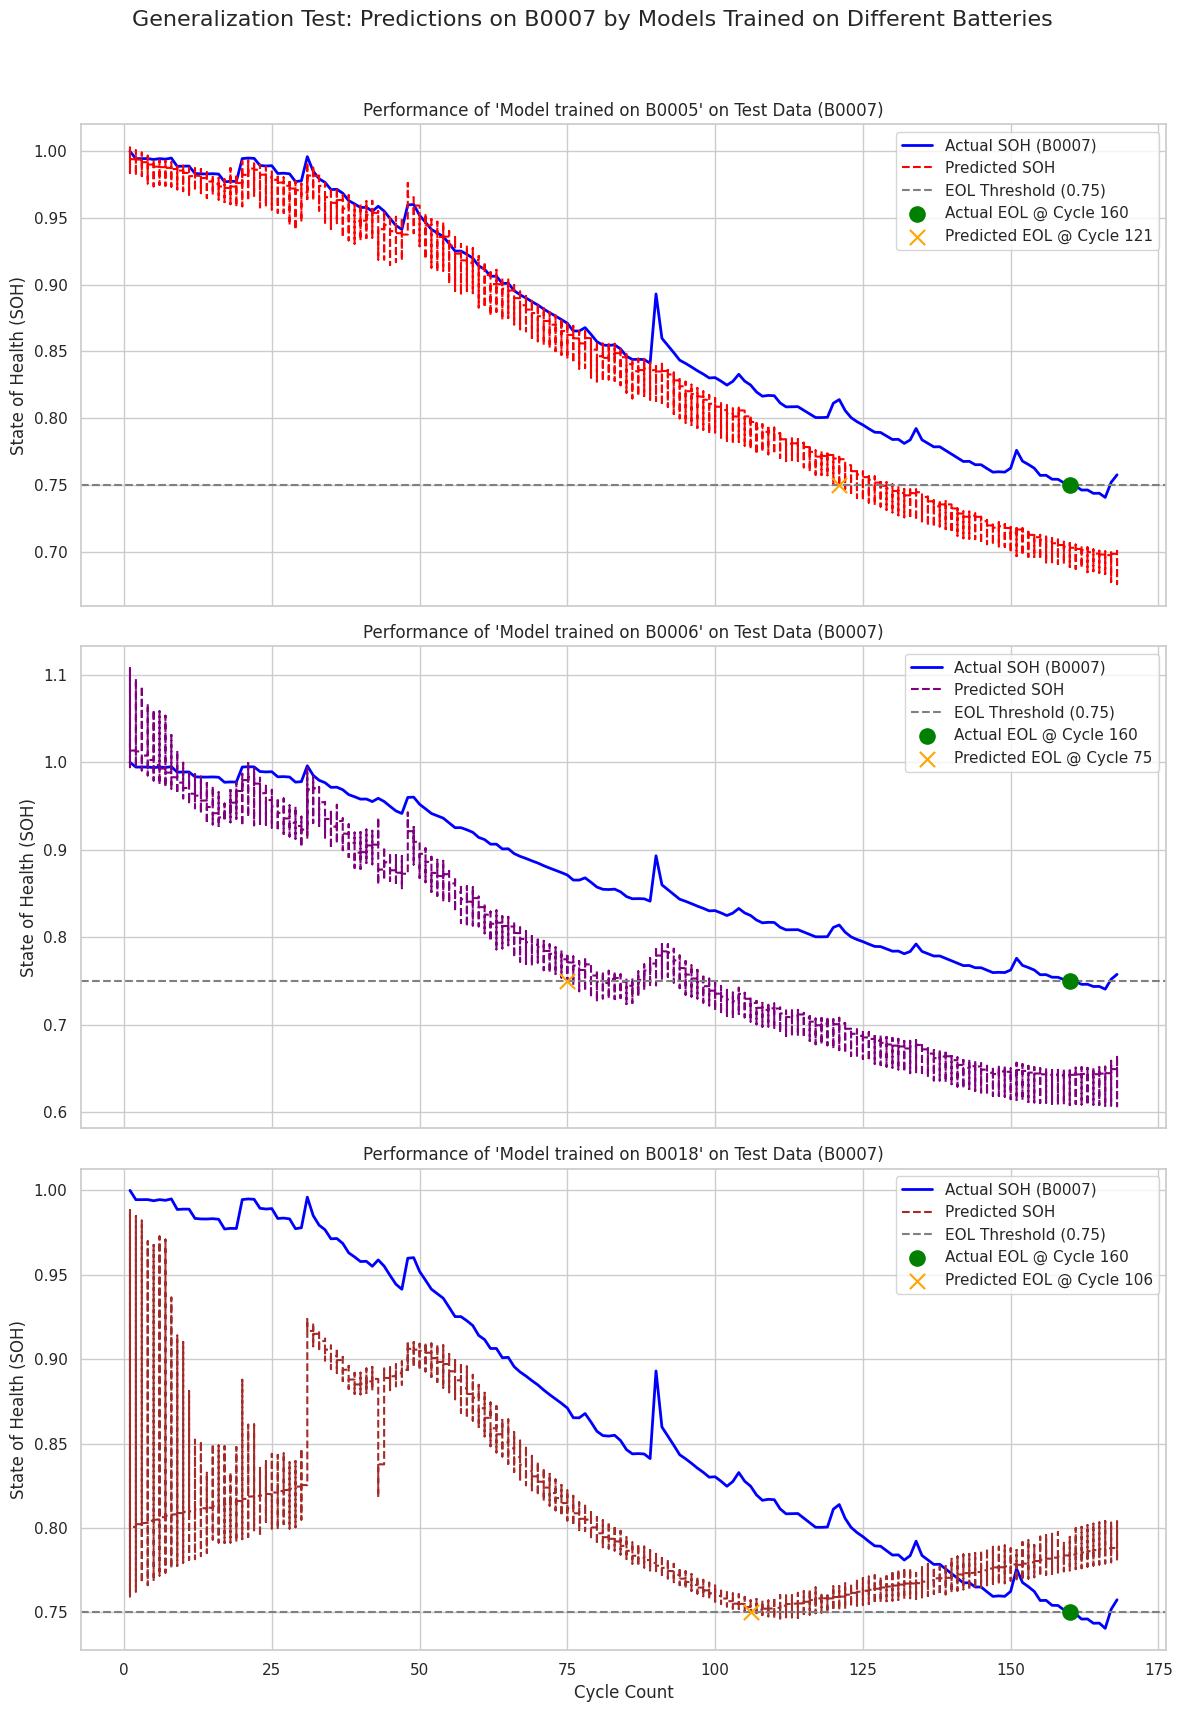

In [ ]:
# 실제 SOH가 임계값 이하로 떨어진 첫 사이클 (실제 EOL)
real_eol_indices = np.where(y_test_actual < threshold)[0]
real_soh_cycle = df_test['cycle'].values[seq_length + real_eol_indices[0]] if len(real_eol_indices) > 0 else None

# 시각화 설정
colors = ['red', 'purple', 'brown']
fig, axs = plt.subplots(len(models), 1, figsize=(12, 18), sharex=True)
if len(models) == 1:
    axs = [axs]

# 모델별 예측 그래프 작성
for i, model_name in enumerate(model_names):
    ax = axs[i]
    # (A) 실제 SOH 시계열 (파란색)
    ax.plot(df_test['cycle'].values[seq_length:], y_test_actual, label='Actual SOH (B0007)', color='blue', linewidth=2)
    # (B) 모델 예측 결과 (점선)
    ax.plot(df_test['cycle'].values[seq_length:], model_predictions[i], label='Predicted SOH', color=colors[i], linestyle='--')
    # (C) 임계값 선 (회색 점선)
    ax.axhline(y=threshold, color='grey', linestyle='--', label=f'EOL Threshold ({threshold})')
    # (D) 실제 EOL 지점 표시 (초록 원)
    if real_soh_cycle is not None:
        ax.scatter(real_soh_cycle, threshold, color='green', s=120, marker='o', label=f'Actual EOL @ Cycle {real_soh_cycle}', zorder=5)
    # (E) 모델의 EOL 예측 지점 표시 (주황 X)
    pred_cycle = eol_predictions[i]
    if pred_cycle is not None:
        ax.scatter(pred_cycle, threshold, color='orange', s=120, marker='x', label=f'Predicted EOL @ Cycle {pred_cycle}', zorder=5)
    # (F) 레이블 및 스타일 설정
    ax.set_title(f"Performance of '{model_name}' on Test Data (B0007)")
    ax.set_ylabel('State of Health (SOH)')
    ax.legend()
    ax.grid(True)

# 공통 X축 라벨 및 전체 제목
axs[-1].set_xlabel('Cycle Count')
fig.suptitle('Generalization Test: Predictions on B0007 by Models Trained on Different Batteries', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

### 4.5 모델 앙상블(Model Ensemble)

여러 개의 LSTM 모델을 조합하는 앙상블(ensemble) 기법 중 하나로, 예측 결과의 Ridge 회귀 기반의 블렌딩(blending) 방법을 적용하여 최종 SOH 예측 성능을 향상시킵니다.

여러 모델의 예측 결과를 조합하여 최종 예측 값을 생성합니다.

- 앙상블 방법 중 **스태킹 (Stacking - Ridge Blending)** 사용

개별 모델의 예측 결과를 새로운 입력 피처로 사용하고, 실제 타겟 값을 사용하여 새로운 모델을 학습시키는 방식

In [ ]:
# 개별 모델들의 예측 결과를 가로 방향으로 합쳐서 하나의 입력 데이터로 만듦
# predictions는 [배터리1 예측 배열, 배터2 예측 배열, 배터리3 예측 배열] 형태의 리스트
# 각 예측 배열은 (예측 샘플 수, 1) 형태
# hstack을 사용하면 (예측 샘플 수, 모델 수) 형태의 배열이 됨
combined_predictions = np.hstack(model_predictions)
print(f"Blending 모델 입력 데이터 (합쳐진 예측 결과) shape: {combined_predictions.shape}")

# Blending 모델 학습에 사용할 실제 타겟 값 (테스트 데이터의 실제 SOH)
# LSTM 예측 결과는 seq_length 시점 이후부터 나오므로, 실제 SOH 값도 그만큼 잘라내야 함
y_test_actual = df_test['SOH'].values[seq_length:]
print(f"Blending 모델 타겟 데이터 (실제 SOH) shape: {y_test_actual.shape}")

# Ridge 회귀 모델을 Blending 모델로 사용
print("Ridge Blending 모델 학습 중...")
blending_model = Ridge()
# 합쳐진 예측 결과(combined_predictions)를 입력으로, 실제 테스트 SOH(y_test_actual)를 타겟으로 학습
blending_model.fit(combined_predictions, y_test_actual)
print("Ridge Blending 모델 학습 완료.")

# 학습된 Blending 모델로 최종 예측 수행
final_predictions = blending_model.predict(combined_predictions)
print(f"최종 Blending 모델 예측 결과 shape: {final_predictions.shape}")

Blending 모델 입력 데이터 (합쳐진 예측 결과) shape: (50277, 3)
Blending 모델 타겟 데이터 (실제 SOH) shape: (50277,)
Ridge Blending 모델 학습 중...
Ridge Blending 모델 학습 완료.
최종 Blending 모델 예측 결과 shape: (50277,)


최종 앙상블 모델의 예측 성능을 평가하고, 실제 SOH 값과 예측 값을 그래프로 비교하여 시각적으로 결과를 확인합니다.

In [ ]:
# 배터리 수명 임계값 설정 (0.75)
threshold = 0.75

# 실제 SOH 값이 임계값(0.75) 이하로 떨어진 첫 번째 지점 찾기
# y_test_actual은 이미 seq_length 이후의 실제 SOH 값입니다.
# np.where는 조건을 만족하는 인덱스 반환. [0]은 첫 번째 튜플(행 인덱스) 가져옴.
real_soh_below_threshold_indices = np.where(y_test_actual <= threshold)[0]

# 실제 SOH가 임계값 아래로 떨어진 지점이 있다면
if len(real_soh_below_threshold_indices) > 0:
    # 임계값 아래로 처음 떨어진 인덱스
    first_real_soh_index = real_soh_below_threshold_indices[0]
    # 해당 인덱스에 해당하는 cycle 번호 가져오기
    # df_test['cycle']에서 seq_length 이후의 cycle 값 배열 사용
    real_soh_cycle = df_test['cycle'].values[seq_length:][first_real_soh_index]
else:
    # 임계값 아래로 떨어진 지점이 없다면 None 설정
    first_real_soh_index = None
    real_soh_cycle = None
    print("주의: 실제 SOH는 모든 테스트 기간 동안 임계값 아래로 떨어지지 않았습니다.")


# 최종 예측 값이 임계값(0.75) 이하로 떨어진 첫 번째 지점 찾기
predictions_below_threshold_indices = np.where(final_predictions <= threshold)[0]

# 예측 값이 임계값 아래로 떨어진 지점이 있다면
if len(predictions_below_threshold_indices) > 0:
    # 임계값 아래로 처음 떨어진 인덱스
    first_pred_index = predictions_below_threshold_indices[0]
    # 해당 인덱스에 해당하는 cycle 번호 가져오기
    pred_cycle = df_test['cycle'].values[seq_length:][first_pred_index]
else:
    # 임계값 아래로 떨어진 지점이 없다면 None 설정
    first_pred_index = None
    pred_cycle = None
    print("주의: 예측된 SOH는 모든 테스트 기간 동안 임계값 아래로 떨어지지 않았습니다.")

# 실제 RUL Cycle과 예측 RUL Cycle 출력
print(f"실제 RUL (SOH <= {threshold}) Cycle: {real_soh_cycle}")
print(f"예측 RUL (SOH <= {threshold}) Cycle: {pred_cycle}")

실제 RUL (SOH <= 0.75) Cycle: 160
예측 RUL (SOH <= 0.75) Cycle: 146


테스트 데이터의 실제 SOH 변화 추이와 최종 앙상블 모델의 예측 결과를 같은 그래프에 그려 비교합니다.

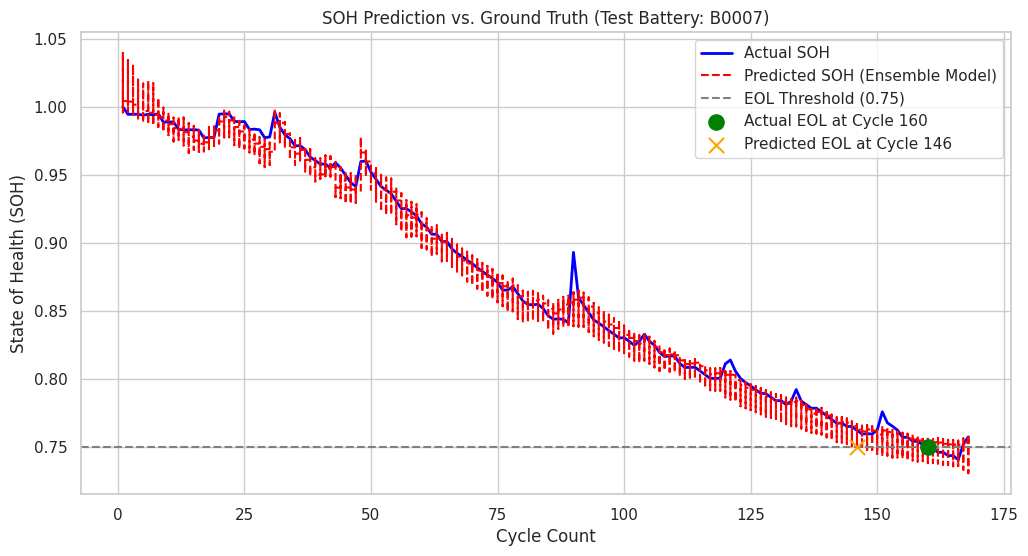

In [ ]:
# === Figure 설정 ===
plt.figure(figsize=(12, 6))

# --- 실제 SOH (Ground Truth) ---
# LSTM 예측이 seq_length 이후 시점부터 시작되므로 해당 구간부터 SOH 시계열을 시각화
plt.plot(df_test['cycle'].values[seq_length:], y_test_actual, label='Actual SOH', color='blue', linewidth=2)

# --- 예측 SOH (Model Prediction) ---
# 앙상블 모델을 통한 예측 결과를 점선으로 시각화
plt.plot(df_test['cycle'].values[seq_length:], final_predictions, label='Predicted SOH (Ensemble Model)', color='red', linestyle='--')

# --- 수명 종료 기준선 및 지점 표시 ---
# (A) EOL 기준선 (e.g., SOH = 0.75)
plt.axhline(y=threshold, color='grey', linestyle='--', label=f'EOL Threshold ({threshold})')

# (B) 실제 수명 종료 시점 표시 (green circle)
if real_soh_cycle is not None:
    plt.scatter(real_soh_cycle, threshold, color='green', s=120, marker='o',
                label=f'Actual EOL at Cycle {real_soh_cycle}', zorder=5)

# (C) 예측된 수명 종료 시점 표시 (orange cross)
if pred_cycle is not None:
    plt.scatter(pred_cycle, threshold, color='orange', s=120, marker='x',
                label=f'Predicted EOL at Cycle {pred_cycle}', zorder=5)

# --- 시각화 세부 설정 ---
plt.title('SOH Prediction vs. Ground Truth (Test Battery: B0007)')
plt.xlabel('Cycle Count')
plt.ylabel('State of Health (SOH)')
plt.legend()
plt.grid(True)

# --- 그래프 출력 ---
plt.show()

모델의 예측 정확도를 정량적으로 평가하기 위해 평균 제곱 오차(MSE)와 결정 계수(R²) 지표를 계산합니다.

-   **MSE (Mean Squared Error):** 실제 값과 예측 값 차이의 제곱 평균. 값이 작을수록 모델 성능이 좋습니다.
-   **R² (R-squared):** 모델이 실제 값의 분산을 얼마나 잘 설명하는지를 나타내는 지표. 0에서 1 사이 값(때로는 음수)을 가지며, 1에 가까울수록 모델 성능이 좋습니다.

In [ ]:
print("\n--- 모델 성능 평가 ---")

# 실제 SOH 값과 최종 예측 값 가져오기
y_true = y_test_actual   # 실제 SOH 값 (seq_length 이후)
y_pred = final_predictions # 예측된 SOH 값 (seq_length 이후)

# Mean Squared Error (MSE) 계산
mse = mean_squared_error(y_true, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4e}")

# R-squared (R²) 계산
r2 = r2_score(y_true, y_pred)
print(f"R-squared (R²): {r2:.4f}")

print("\n--- 모델 성능 평가 완료 ---")


--- 모델 성능 평가 ---
Mean Squared Error (MSE): 4.7558e-05
R-squared (R²): 0.9927

--- 모델 성능 평가 완료 ---
